# Proyecto: Clasificación de Textos en Lenguaje Natural
## Autor: Raúl González Acosta ([alu0101543529](mailto:alu0101543529@ull.edu.es))
### Descripción del Proyecto
En este proyecto, se desarrollará un modelo de clasificación de textos utilizando técnicas de procesamiento de lenguaje natural (NLP).

El objetivo es clasificar textos en diferentes categorías, como noticias, opiniones,o reseñas, utilizando un conjunto de datos etiquetado. El proyecto se llevará a cabo en varias etapas, incluyendo la recopilación y preprocesamiento de datos, la selección y entrenamiento de modelos de clasificación, y la evaluación del rendimiento del modelo.

Se utilizarán bibliotecas de Python como NLTK, Scikit-learn y TensorFlow para implementar las diferentes etapas del proyecto.

Al final, se espera obtener un modelo de clasificación de textos preciso y eficiente que pueda ser utilizado para clasificar nuevos textos en las categorías definidas.

## FASE 1: Preprocesamiento, Tokenización, Creación del Vocabulario y Conjunto de Entrenamiento

En esta primera sección realizaremos todas las operaciones de preprocesamiento necesarias para preparar los datos crudos (corpus de poesía y rap) para ser utilizados por los modelos de aprendizaje automático.

## 1. Importación de Librerías Necesarias

A continuación se importan todas las herramientas requeridas para:
- **Procesamiento de lenguaje natural:** NLTK con stopwords, tokenización y stemming en español
- **Manipulación de datos:** Expresiones regulares, diccionarios y contadores
- **Análisis y visualización:** NumPy y Pandas para análisis estadístico

Estas librerías serán fundamentales para normalizar y limpiar el texto crudo de entrada.

In [2]:
# Librerías estándar de Python
import re
import os
from collections import defaultdict, Counter
import json

# Librerías para procesamiento de lenguaje natural
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import word_tokenize

# Librerías para visualización
import pandas as pd
import numpy as np
from collections import Counter

# Descargar recursos necesarios de NLTK
nltk.download('punkt_tab', quiet=True)  # Tokenizador
nltk.download('stopwords', quiet=True)  # Palabras vacías en español

True

## 2. Clase para Corrección Ortográfica

En este siguiente bloque de código se implementa un corrector ortográfico simple que utiliza la **distancia de Levenshtein** para identificar y corregir palabras mal escritas. Este paso es importante para mejorar la calidad de los datos, permitiendo que variaciones ortográficas de la misma palabra sean tratadas de manera coherente por el modelo.

In [3]:
class CorrectOrSpellChecker:
    """
    Clase para realizar corrección ortográfica básica.
    Utiliza un diccionario de palabras conocidas y calcula la distancia de Levenshtein
    para encontrar la palabra correcta más cercana.
    """

    def __init__(self):
        """
        Inicializa el corrector ortográfico con un diccionario básico de palabras españolas.
        """
        # Diccionario de palabras españolas comunes
        self.dictionary = set([
            'el', 'la', 'de', 'que', 'y', 'a', 'en', 'un', 'ser', 'se', 'no', 'haber',
            'por', 'con', 'su', 'para', 'es', 'un', 'está', 'como', 'está', 'fue',
            'amor', 'vida', 'tiempo', 'mundo', 'corazón', 'noche', 'día', 'luz',
            'muerte', 'cuerpo', 'alma', 'voz', 'palabra', 'verso', 'poesía',
            'canción', 'música', 'ritmo', 'rap', 'hip', 'hop', 'flow'
        ])

    def levenshtein_distance(self, s1, s2):
        """
        Calcula la distancia de Levenshtein entre dos palabras.
        Mide el número mínimo de ediciones (inserciones, eliminaciones, sustituciones)
        necesarias para transformar una palabra en otra.

        Parámetros:
            s1 (str): Primera palabra
            s2 (str): Segunda palabra

        Retorna:
            int: Distancia de Levenshtein
        """
        if len(s1) < len(s2):
            return self.levenshtein_distance(s2, s1)

        if len(s2) == 0:
            return len(s1)

        previous_row = range(len(s2) + 1)
        for i, c1 in enumerate(s1):
            current_row = [i + 1]
            for j, c2 in enumerate(s2):
                insertions = previous_row[j + 1] + 1
                deletions = current_row[j] + 1
                substitutions = previous_row[j] + (c1 != c2)
                current_row.append(min(insertions, deletions, substitutions))
            previous_row = current_row

        return previous_row[-1]

    def correct_word(self, word, max_distance=2):
        """
        Intenta corregir una palabra si está en el diccionario.
        Si la palabra no está en el diccionario, busca la palabra más similar
        con una distancia de Levenshtein menor a max_distance.

        Parámetros:
            word (str): Palabra a corregir
            max_distance (int): Distancia máxima para considerar una corrección

        Retorna:
            str: Palabra corregida o la palabra original si no se encuentra corrección
        """
        # Si la palabra está en el diccionario, no corregir
        if word in self.dictionary:
            return word

        # Si la palabra es muy corta, no intentar corregir
        if len(word) <= 2:
            return word

        # Buscar la palabra más similar en el diccionario
        closest_word = word
        min_distance = max_distance

        for dict_word in self.dictionary:
            distance = self.levenshtein_distance(word, dict_word)
            if distance < min_distance:
                min_distance = distance
                closest_word = dict_word

        return closest_word

## 3. Clase para Lematización

También se hace un proceso de **lematización**, que consiste en reducir las palabras a su forma canónica mediante el algoritmo de Snowball adaptado para español. Esto es crucial para normalizar variaciones morfológicas: palabras como "corriendo", "corrió" y "correr" se reducen al mismo lema, mejorando la consistencia en el análisis.

In [4]:
class LemmatizerSpanish:
    """
    Clase para realizar lematización en español.
    Utiliza el lematizador de Snowball de NLTK adaptado para español.

    Lematización: Proceso de reducir palabras a su forma canónica o lema.
    Ejemplo: "corriendo", "correr", "corrió" -> "corr"
    """

    def __init__(self):
        """
        Inicializa el lematizador con el idioma español.
        """
        self.stemmer = SnowballStemmer('spanish')

    def lemmatize_word(self, word):
        """
        Lematiza una palabra individual.

        Parámetros:
            word (str): Palabra a lematizar

        Retorna:
            str: Palabra lematizada
        """
        return self.stemmer.stem(word)

    def lemmatize_text(self, words):
        """
        Lematiza una lista de palabras.

        Parámetros:
            words (list): Lista de palabras a lematizar

        Retorna:
            list: Lista de palabras lematizadas
        """
        return [self.lemmatize_word(word) for word in words]

## 4. Clase Principal para Preprocesamiento

Para unificar todas las etapas de forma ordenada y clara, se implementa la clase `TextPreprocessor` que encapsula todo el flujo de preprocesamiento en la siguiente secuencia:
1. **Conversión a minúsculas:** Normalización de caracteres para coherencia
2. **Eliminación de puntuación:** Preservación solo de palabras significativas
3. **Eliminación de números:** Reducción de ruido en el análisis
4. **Tokenización:** División del texto en palabras individuales
5. **Eliminación de stopwords:** Filtrado de palabras poco significativas en español
6. **Corrección ortográfica:** Corrección de errores de escritura
7. **Lematización:** Reducción a formas canónicas

El resultado es un conjunto limpio y normalizado de palabras listas para análisis posterior.

In [5]:
class TextPreprocessor:
    """
    Clase principal para realizar el preprocesamiento completo de textos.
    Incluye todas las operaciones de limpieza y normalización necesarias.
    """

    def __init__(self):
        """
        Inicializa el preprocesador con todas las herramientas necesarias.
        """
        # Obtener las palabras vacías (stopwords) en español
        self.stop_words = set(stopwords.words('spanish'))

        # Inicializar el lematizador
        self.lemmatizer = LemmatizerSpanish()

        # Inicializar el corrector ortográfico
        self.spell_checker = CorrectOrSpellChecker()

    def to_lowercase(self, text):
        """
        TAREA 1: Convierte el texto a minúsculas.
        Esto asegura que palabras como "Casa" y "casa" sean tratadas igual.

        Parámetros:
            text (str): Texto original

        Retorna:
            str: Texto en minúsculas
        """
        return text.lower()

    def remove_punctuation(self, text):
        """
        TAREA 2: Elimina los signos de puntuación del texto.
        Se preservan los espacios en blanco.
        Ejemplos: "¡Hola!" -> "Hola", "Casa, mesa." -> "Casa mesa"

        Parámetros:
            text (str): Texto con puntuación

        Retorna:
            str: Texto sin puntuación
        """
        # Usar expresión regular para eliminar caracteres de puntuación
        # Se mantienen letras, números, espacios y caracteres especiales de EOL
        text = re.sub(r'[!"#$%&\'()*+,-./:;<=>?@[\]^_`{|}~¡¿]', ' ', text)
        # Eliminar espacios múltiples
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def remove_numbers(self, text):
        """
        TAREA 3: Elimina los números del texto.
        Ejemplos: "Casa 123" -> "Casa", "Año 2026" -> "Año"

        Parámetros:
            text (str): Texto con números

        Retorna:
            str: Texto sin números
        """
        # Usar expresión regular para eliminar dígitos
        text = re.sub(r'\d+', ' ', text)
        # Eliminar espacios múltiples
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def remove_stopwords(self, words):
        """
        TAREA 4: Elimina las palabras reservadas (stopwords) del texto tokenizado.
        Las stopwords son palabras muy comunes que no aportan significado importante:
        el, la, de, que, y, a, en, un, ser, se, no, haber, por, con, etc.

        Parámetros:
            words (list): Lista de palabras tokenizadas

        Retorna:
            list: Lista de palabras sin stopwords
        """
        filtered_words = [word for word in words if word.lower() not in self.stop_words]
        return filtered_words

    def correct_spelling(self, words):
        """
        TAREA 5: Realiza corrección ortográfica en las palabras.
        Intenta corregir palabras mal escritas usando distancia de Levenshtein.

        Parámetros:
            words (list): Lista de palabras a corregir

        Retorna:
            list: Lista de palabras corregidas
        """
        corrected_words = [self.spell_checker.correct_word(word) for word in words]
        return corrected_words

    def lemmatize(self, words):
        """
        TAREA 6: Realiza lematización en las palabras.
        Reduce las palabras a su forma canónica:
        Ejemplos: "corriendo", "corrió", "correr" -> "corr"
                  "hermana", "hermano", "hermanas" -> "herman"

        Parámetros:
            words (list): Lista de palabras a lematizar

        Retorna:
            list: Lista de palabras lematizadas
        """
        lemmatized_words = self.lemmatizer.lemmatize_text(words)
        return lemmatized_words

    def tokenize(self, text):
        """
        Divide el texto en tokens (palabras individuales).
        Utiliza el tokenizador de NLTK para español.

        Parámetros:
            text (str): Texto a tokenizar

        Retorna:
            list: Lista de tokens (palabras)
        """
        # Tokenizar usando el tokenizador de NLTK especificando español
        tokens = word_tokenize(text, language='spanish')
        # Filtrar tokens vacíos
        tokens = [token for token in tokens if token.strip()]
        return tokens

    def preprocess_text(self, text, remove_stopwords_flag=True, apply_spell_check=True, apply_lemmatization=True):
        """
        Aplica el preprocesamiento completo al texto en el siguiente orden:
        1. Convertir a minúsculas
        2. Eliminar signos de puntuación
        3. Eliminar números
        4. Tokenización
        5. Eliminación de stopwords (opcional)
        6. Corrección ortográfica (opcional)
        7. Lematización (opcional)

        Parámetros:
            text (str): Texto a preprocesar
            remove_stopwords_flag (bool): Si True, elimina stopwords
            apply_spell_check (bool): Si True, realiza corrección ortográfica
            apply_lemmatization (bool): Si True, realiza lematización

        Retorna:
            list: Lista de palabras preprocesadas
        """
        # Paso 1: Convertir a minúsculas
        text = self.to_lowercase(text)

        # Paso 2: Eliminar signos de puntuación
        text = self.remove_punctuation(text)

        # Paso 3: Eliminar números
        text = self.remove_numbers(text)

        # Paso 4: Tokenización
        tokens = self.tokenize(text)

        # Paso 5: Eliminar stopwords
        if remove_stopwords_flag:
            tokens = self.remove_stopwords(tokens)

        # Paso 6: Corrección ortográfica
        if apply_spell_check:
            tokens = self.correct_spelling(tokens)

        # Paso 7: Lematización
        if apply_lemmatization:
            tokens = self.lemmatize(tokens)

        return tokens

## 5. Carga de los Corpus

En esta sección se cargan los archivos de texto que contienen poemas y canciones de rap. Los corpus están estructurados con delimitadores especiales (`<CS>` y `</CS>`) que permiten separar cada texto individual. Este paso es el primero del pipeline de datos, proporcionando la materia prima para todo el procesamiento posterior.

In [6]:
def load_corpus(filepath):
    """
    Carga un corpus desde un archivo de texto.
    El corpus tiene un formato especial con delimitadores <CS> y </CS>
    para separar poemas/canciones individuales.

    Parámetros:
        filepath (str): Ruta del archivo del corpus

    Retorna:
        list: Lista de textos individuales (poemas/canciones)
    """
    texts = []

    try:
        with open(filepath, 'r', encoding='utf-8-sig') as file:
            content = file.read()

        # Dividir por delimitadores <CS> y </CS>
        # Buscar todos los textos entre estos delimitadores
        pattern = r'<CS>\s*(.*?)\s*</CS>'
        matches = re.findall(pattern, content, re.DOTALL)

        for match in matches:
            # Reemplazar el marcador de fin de línea <EOL> por espacios
            # para mantener la separación entre palabras de diferentes líneas
            text = match.replace('<EOL>', ' ')
            # Limpiar espacios múltiples
            text = re.sub(r'\s+', ' ', text).strip()
            if text:  # Solo incluir textos no vacíos
                texts.append(text)

        print(f"✓ Corpus cargado desde {filepath}")
        print(f"  Total de textos cargados: {len(texts)}")

    except FileNotFoundError:
        print(f"✗ Error: No se encontró el archivo {filepath}")
    except Exception as e:
        print(f"✗ Error al cargar el corpus: {e}")

    return texts

# Rutas de los corpus
corpus_dir = 'corpus'
poesia_path = os.path.join(corpus_dir, 'poesia.txt')
rap_path = os.path.join(corpus_dir, 'rap.txt')

# Cargar los corpus
poesia_texts = load_corpus(poesia_path)
rap_texts = load_corpus(rap_path)

print(f"Total de textos: {len(poesia_texts) + len(rap_texts)}")

✓ Corpus cargado desde corpus/poesia.txt
  Total de textos cargados: 4000
✓ Corpus cargado desde corpus/rap.txt
  Total de textos cargados: 1456
Total de textos: 5456


## 6. Demostración del Preprocesamiento

A continuación, se ejecuta un ejemplo paso a paso del preprocesamiento sobre un fragmento de texto de prueba, mostrando el resultado de cada etapa. Esto permite visualizar cómo el texto se transforma desde su forma original hasta convertirse en una lista limpia de palabras lematizadas.

In [7]:
# Crear una instancia del preprocesador
preprocessor = TextPreprocessor()

# Seleccionar un texto de ejemplo
if len(poesia_texts) > 0:
    example_text = poesia_texts[0][:200]  # Primeros 200 caracteres
    print("\n" + "="*70)
    print("DEMOSTRACIÓN DEL PREPROCESAMIENTO")
    print("="*70 + "\n")

    print("TEXTO ORIGINAL:")
    print(f"{example_text}\n")

    # Mostrar cada paso del preprocesamiento
    step1 = preprocessor.to_lowercase(example_text)
    print("PASO 1 - Convertir a minúsculas:")
    print(f"{step1}\n")

    step2 = preprocessor.remove_punctuation(step1)
    print("PASO 2 - Eliminar puntuación:")
    print(f"{step2}\n")

    step3 = preprocessor.remove_numbers(step2)
    print("PASO 3 - Eliminar números:")
    print(f"{step3}\n")

    step4 = preprocessor.tokenize(step3)
    print("PASO 4 - Tokenización:")
    print(f"{step4}\n")

    step5 = preprocessor.remove_stopwords(step4)
    print("PASO 5 - Eliminar stopwords:")
    print(f"{step5}\n")

    step6 = preprocessor.lemmatize(step5)
    print("PASO 6 - Lematización:")
    print(f"{step6}\n")


DEMOSTRACIÓN DEL PREPROCESAMIENTO

TEXTO ORIGINAL:
En el parque confuso Que con lánguidas brisas el cielo sahúma, El ciprés, como un huso, Devana un ovillo de de bruma. El telar de la luna tiende en plata su urdimbre; Abandona la rada un lúgubre corsa

PASO 1 - Convertir a minúsculas:
en el parque confuso que con lánguidas brisas el cielo sahúma, el ciprés, como un huso, devana un ovillo de de bruma. el telar de la luna tiende en plata su urdimbre; abandona la rada un lúgubre corsa

PASO 2 - Eliminar puntuación:
en el parque confuso que con lánguidas brisas el cielo sahúma el ciprés como un huso devana un ovillo de de bruma el telar de la luna tiende en plata su urdimbre abandona la rada un lúgubre corsa

PASO 3 - Eliminar números:
en el parque confuso que con lánguidas brisas el cielo sahúma el ciprés como un huso devana un ovillo de de bruma el telar de la luna tiende en plata su urdimbre abandona la rada un lúgubre corsa

PASO 4 - Tokenización:
['en', 'el', 'parque', 'confuso', 'qu

## 7. Preprocesamiento Completo de Todos los Textos

Una vez vista la implementación y su funcionamiento, se aplica el pipeline completo de preprocesamiento a todos los textos de ambos corpus (poesía y rap). Este es un paso computacionalmente intenso que prepara los datos para análisis posterior. El resultado es un conjunto de textos normalizados listos para construcción del vocabulario y entrenamiento de modelos.

In [8]:
# Preprocesar todos los poemas
print("Preprocesando poemas...")
poesia_preprocessed = []
for i, text in enumerate(poesia_texts):
    processed = preprocessor.preprocess_text(
        text,
        remove_stopwords_flag=True,
        apply_spell_check=True,
        apply_lemmatization=True
    )
    poesia_preprocessed.append(processed)
    if (i + 1) % 5 == 0:
        print(f"  ✓ Procesados {i + 1}/{len(poesia_texts)} poemas")

print(f"✓ {len(poesia_preprocessed)} poemas preprocesados correctamente\n")

# Preprocesar todas las canciones de rap
print("Preprocesando canciones de rap...")
rap_preprocessed = []
for i, text in enumerate(rap_texts):
    processed = preprocessor.preprocess_text(
        text,
        remove_stopwords_flag=True,
        apply_spell_check=True,
        apply_lemmatization=True
    )
    rap_preprocessed.append(processed)
    if (i + 1) % 5 == 0:
        print(f"  ✓ Procesadas {i + 1}/{len(rap_texts)} canciones de rap")

print(f"✓ {len(rap_preprocessed)} canciones de rap preprocesadas correctamente\n")

# Combinación de ambos corpus
all_preprocessed = poesia_preprocessed + rap_preprocessed
all_labels = [0] * len(poesia_preprocessed) + [1] * len(rap_preprocessed)  # 0 = poesía, 1 = rap

print(f"\nTotal de textos preprocesados: {len(all_preprocessed)}")

Preprocesando poemas...
  ✓ Procesados 5/4000 poemas
  ✓ Procesados 10/4000 poemas
  ✓ Procesados 15/4000 poemas
  ✓ Procesados 20/4000 poemas
  ✓ Procesados 25/4000 poemas
  ✓ Procesados 30/4000 poemas
  ✓ Procesados 35/4000 poemas
  ✓ Procesados 40/4000 poemas
  ✓ Procesados 45/4000 poemas
  ✓ Procesados 50/4000 poemas
  ✓ Procesados 55/4000 poemas
  ✓ Procesados 60/4000 poemas
  ✓ Procesados 65/4000 poemas
  ✓ Procesados 70/4000 poemas
  ✓ Procesados 75/4000 poemas
  ✓ Procesados 80/4000 poemas
  ✓ Procesados 85/4000 poemas
  ✓ Procesados 90/4000 poemas
  ✓ Procesados 95/4000 poemas
  ✓ Procesados 100/4000 poemas
  ✓ Procesados 105/4000 poemas
  ✓ Procesados 110/4000 poemas
  ✓ Procesados 115/4000 poemas
  ✓ Procesados 120/4000 poemas
  ✓ Procesados 125/4000 poemas
  ✓ Procesados 130/4000 poemas
  ✓ Procesados 135/4000 poemas
  ✓ Procesados 140/4000 poemas
  ✓ Procesados 145/4000 poemas
  ✓ Procesados 150/4000 poemas
  ✓ Procesados 155/4000 poemas
  ✓ Procesados 160/4000 poemas
  ✓ 

## 8. Creación del Vocabulario

Con los textos ya preprocesados, se construye un **vocabulario** que es el conjunto de todas las palabras únicas encontradas en los corpus procesados. Cada palabra recibe un índice numérico único que será utilizado para convertir el texto en representaciones numéricas que los modelos de red neuronal puedan procesar. También se registra la frecuencia de cada palabra para análisis posterior.

In [9]:
class Vocabulary:
    """
    Clase para gestionar el vocabulario de palabras del corpus.
    Mantiene un mapeo bidireccional entre palabras e índices.
    """

    def __init__(self):
        """
        Inicializa el vocabulario vacío.
        """
        self.word_to_idx = {}  # Mapeo: palabra -> índice
        self.idx_to_word = {}  # Mapeo: índice -> palabra
        self.word_freq = Counter()  # Frecuencia de cada palabra
        self.size = 0  # Número total de palabras únicas

    def add_word(self, word):
        """
        Añade una palabra al vocabulario si no existe.

        Parámetros:
            word (str): Palabra a añadir
        """
        if word not in self.word_to_idx:
            self.word_to_idx[word] = self.size
            self.idx_to_word[self.size] = word
            self.size += 1
        self.word_freq[word] += 1

    def build_from_texts(self, texts):
        """
        Construye el vocabulario a partir de una lista de textos preprocesados.

        Parámetros:
            texts (list): Lista de listas de palabras
        """
        for text in texts:
            for word in text:
                self.add_word(word)

    def encode(self, words):
        """
        Convierte una lista de palabras en sus índices correspondientes.

        Parámetros:
            words (list): Lista de palabras

        Retorna:
            list: Lista de índices
        """
        unk_idx = self.word_to_idx.get('<UNK>', 0)
        return [self.word_to_idx.get(word, unk_idx) for word in words]

    def decode(self, indices):
        """
        Convierte una lista de índices en sus palabras correspondientes.

        Parámetros:
            indices (list): Lista de índices

        Retorna:
            list: Lista de palabras
        """
        return [self.idx_to_word.get(idx, '<UNK>') for idx in indices]

    def get_frequency_rank(self, top_n=20):
        """
        Retorna las N palabras más frecuentes del vocabulario.

        Parámetros:
            top_n (int): Número de palabras top a retornar

        Retorna:
            list: Lista de tuplas (palabra, frecuencia)
        """
        return self.word_freq.most_common(top_n)

    def __len__(self):
        """Retorna el tamaño del vocabulario."""
        return self.size

# Crear y construir el vocabulario a partir de los textos preprocesados
vocab = Vocabulary()
vocab.build_from_texts(all_preprocessed)

print(f"Palabras únicas en el corpus: {len(vocab)}")
print(f"\nPalabras más frecuentes (Top 20):")
for i, (word, freq) in enumerate(vocab.get_frequency_rank(20), 1):
    print(f"  {i:2d}. {word:20s} -> {freq:4d} veces")

Palabras únicas en el corpus: 32917

Palabras más frecuentes (Top 20):
   1. si                   -> 7572 veces
   2. sol                  -> 6301 veces
   3. ser                  -> 4656 veces
   4. quier                -> 4379 veces
   5. vid                  -> 4290 veces
   6. voz                  -> 3831 veces
   7. amor                 -> 3504 veces
   8. muert                -> 3236 veces
   9. dia                  -> 2963 veces
  10. mir                  -> 2934 veces
  11. pued                 -> 2864 veces
  12. pas                  -> 2806 veces
  13. hac                  -> 2698 veces
  14. par                  -> 2667 veces
  15. viv                  -> 2611 veces
  16. siempr               -> 2588 veces
  17. alma                 -> 2586 veces
  18. noch                 -> 2417 veces
  19. dej                  -> 2395 veces
  20. sab                  -> 2229 veces


## 9. Análisis Estadístico del Preprocesamiento

En esta sección vemos unas estadísticas descriptivas sobre los datos preprocesados para caracterizar los corpus:
- Número total de documentos por clase
- Longitud promedio, máxima y mínima de documentos
- Distribución de palabras
- Información del vocabulario

Estas métricas proporcionan una visión general de la calidad y características de los datos.

In [10]:
# Estadísticas de poesía
poesia_word_counts = [len(text) for text in poesia_preprocessed]
poesia_avg_words = np.mean(poesia_word_counts)
poesia_max_words = np.max(poesia_word_counts)
poesia_min_words = np.min(poesia_word_counts)
poesia_total_words = np.sum(poesia_word_counts)

# Estadísticas de rap
rap_word_counts = [len(text) for text in rap_preprocessed]
rap_avg_words = np.mean(rap_word_counts)
rap_max_words = np.max(rap_word_counts)
rap_min_words = np.min(rap_word_counts)
rap_total_words = np.sum(rap_word_counts)

print("ESTADÍSTICAS DE POESÍA:")
print(f"  Número de poemas: {len(poesia_preprocessed)}")
print(f"  Total de palabras: {poesia_total_words}")
print(f"  Promedio de palabras por poema: {poesia_avg_words:.2f}")
print(f"  Máximo de palabras en un poema: {int(poesia_max_words)}")
print(f"  Mínimo de palabras en un poema: {int(poesia_min_words)}")
print(f"  Desviación estándar: {np.std(poesia_word_counts):.2f}")

print("\nESTADÍSTICAS DE RAP:")
print(f"  Número de canciones: {len(rap_preprocessed)}")
print(f"  Total de palabras: {rap_total_words}")
print(f"  Promedio de palabras por canción: {rap_avg_words:.2f}")
print(f"  Máximo de palabras en una canción: {int(rap_max_words)}")
print(f"  Mínimo de palabras en una canción: {int(rap_min_words)}")
print(f"  Desviación estándar: {np.std(rap_word_counts):.2f}")

print("\nESTADÍSTICAS GLOBALES:")
print(f"  Total de documentos: {len(all_preprocessed)}")
print(f"  Total de palabras procesadas: {poesia_total_words + rap_total_words}")
print(f"  Vocabulario único: {len(vocab)} palabras")
print(f"  Promedio de palabras por documento: {(poesia_total_words + rap_total_words) / len(all_preprocessed):.2f}")

ESTADÍSTICAS DE POESÍA:
  Número de poemas: 4000
  Total de palabras: 354246
  Promedio de palabras por poema: 88.56
  Máximo de palabras en un poema: 1946
  Mínimo de palabras en un poema: 1
  Desviación estándar: 107.80

ESTADÍSTICAS DE RAP:
  Número de canciones: 1456
  Total de palabras: 361075
  Promedio de palabras por canción: 247.99
  Máximo de palabras en una canción: 2372
  Mínimo de palabras en una canción: 27
  Desviación estándar: 116.53

ESTADÍSTICAS GLOBALES:
  Total de documentos: 5456
  Total de palabras procesadas: 715321
  Vocabulario único: 32917 palabras
  Promedio de palabras por documento: 131.11


## 10. Creación del Conjunto de Entrenamiento y Prueba

Preparando ahora los datos para el procesamiento, se realiza una división estratificada de los datos en dos conjuntos:
- **Conjunto de Entrenamiento (80%):** Utilizado para que los modelos aprendan patrones
- **Conjunto de Prueba (20%):** Utilizado para evaluar el rendimiento en datos no vistos

La división es **estratificada**, lo que significa que se mantiene la proporción de clases (poesía/rap) en ambos conjuntos, asegurando que el modelo se entrene y evalúe en distribuciones similares.

In [11]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (80%) y prueba (20%)
# Utilizamos random_state para reproducibilidad
train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_preprocessed,
    all_labels,
    test_size=0.2,  # 20% para prueba
    random_state=42,  # Semilla para reproducibilidad
    stratify=all_labels  # Mantener la proporción de clases
)

print(f"Conjunto de ENTRENAMIENTO: {len(train_texts)} textos ({len(train_texts)/len(all_preprocessed)*100:.1f}%)")
print(f"  - Poesía: {sum(1 for label in train_labels if label == 0)}")
print(f"  - Rap: {sum(1 for label in train_labels if label == 1)}")

print(f"\nConjunto de PRUEBA: {len(test_texts)} textos ({len(test_texts)/len(all_preprocessed)*100:.1f}%)")
print(f"  - Poesía: {sum(1 for label in test_labels if label == 0)}")
print(f"  - Rap: {sum(1 for label in test_labels if label == 1)}")

print(f"\nTotal de textos: {len(train_texts) + len(test_texts)}")

Conjunto de ENTRENAMIENTO: 4364 textos (80.0%)
  - Poesía: 3199
  - Rap: 1165

Conjunto de PRUEBA: 1092 textos (20.0%)
  - Poesía: 801
  - Rap: 291

Total de textos: 5456


## 11. Guardado de Datos Preprocesados

Una vez tenemos los conjuntos listos para el entrenamiento, se guardan en archivos JSON para ser utilizados posteriormente:
- **train_data.json:** Textos preprocesados del conjunto de entrenamiento con sus etiquetas
- **test_data.json:** Textos preprocesados del conjunto de prueba con sus etiquetas
- **vocabulary.json:** Mapeo bidireccional entre palabras e índices, así como frecuencias

Esta persistencia permite que las fases posteriores (entrenamiento y clasificación) utilicen exactamente los mismos datos sin necesidad de reprocesar.

In [12]:
# Crear el directorio de salida si no existe
output_dir = 'datos_preprocesados'
os.makedirs(output_dir, exist_ok=True)

# Guardar los datos de entrenamiento
train_data = {
    'texts': train_texts,
    'labels': train_labels
}

test_data = {
    'texts': test_texts,
    'labels': test_labels
}

# Guardar vocabulario
vocab_data = {
    'word_to_idx': vocab.word_to_idx,
    'idx_to_word': vocab.idx_to_word,
    'word_freq': dict(vocab.word_freq)
}

# Guardar en archivos JSON
with open(os.path.join(output_dir, 'train_data.json'), 'w', encoding='utf-8') as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)
    print("✓ Datos de entrenamiento guardados en 'train_data.json'")

with open(os.path.join(output_dir, 'test_data.json'), 'w', encoding='utf-8') as f:
    json.dump(test_data, f, ensure_ascii=False, indent=2)
    print("✓ Datos de prueba guardados en 'test_data.json'")

with open(os.path.join(output_dir, 'vocabulary.json'), 'w', encoding='utf-8') as f:
    json.dump(vocab_data, f, ensure_ascii=False, indent=2)
    print("✓ Vocabulario guardado en 'vocabulary.json'")

print(f"\n✓ Todos los datos se han guardado en: {output_dir}")

✓ Datos de entrenamiento guardados en 'train_data.json'
✓ Datos de prueba guardados en 'test_data.json'
✓ Vocabulario guardado en 'vocabulary.json'

✓ Todos los datos se han guardado en: datos_preprocesados


## FASE 3: Creación y Entrenamiento de Modelos Neuronales

**Objetivo:** Implementar y entrenar tres arquitecturas de redes neuronales diferentes para realizar la clasificación de textos.

**Descripción:** En esta fase se utilizan los datos preprocesados previamente para entrenar modelos de aprendizaje profundo. Se implementarán tres arquitecturas distintas:

1. **Red Neuronal Densa (PAD):** Modelo simple con capas totalmente conectadas. Utiliza embedding de palabras y global average pooling para procesar textos de longitud variable.

2. **Red Neuronal Recurrente (RNN con LSTM):** Modelo que captura dependencias secuenciales en el texto. Procesa las palabras de forma ordenada, recordando información de palabras anteriores mediante celdas LSTM bidireccionales.

3. **Transformer:** Modelo basado en mecanismo de atención multi-cabeza. Permite que cada palabra atienda a todas las demás palabras simultáneamente, capturando relaciones complejas en el texto.

Cada modelo se entrenará, se evaluará en el conjunto de prueba y se guardará para su uso posterior.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch y componentes relacionados
import torch
import torch.nn as nn
import torch.nn.functional as F  # Added this import
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Métricas de evaluación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configurar dispositivo (GPU si está disponible, sino CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo utilizado: {device}")
print(f"PyTorch versión: {torch.__version__}")

Dispositivo utilizado: cuda
PyTorch versión: 2.11.0+cu130


## 1. Importación de Librerías para Aprendizaje Profundo

En este bloque de código, se importan las librerías necesarias para construir y entrenar modelos de redes neuronales con PyTorch. También se configura el dispositivo (GPU si está disponible, o CPU en caso contrario) para optimizar el cálculo.

In [14]:
# Cargar datos preprocesados y vocabulario
data_dir = 'datos_preprocesados'

# Cargar vocabulario
with open(os.path.join(data_dir, 'vocabulary.json'), 'r', encoding='utf-8') as f:
    vocab_data = json.load(f)
    word_to_idx = vocab_data['word_to_idx']
    idx_to_word = {int(k): v for k, v in vocab_data['idx_to_word'].items()}

# Cargar datos de entrenamiento
with open(os.path.join(data_dir, 'train_data.json'), 'r', encoding='utf-8') as f:
    train_data = json.load(f)
    train_texts = train_data['texts']
    train_labels = train_data['labels']

# Cargar datos de prueba
with open(os.path.join(data_dir, 'test_data.json'), 'r', encoding='utf-8') as f:
    test_data = json.load(f)
    test_texts = test_data['texts']
    test_labels = test_data['labels']

print(f"✓ Vocabulario cargado: {len(word_to_idx)} palabras únicas")
print(f"✓ Datos de entrenamiento cargados: {len(train_texts)} textos")
print(f"✓ Datos de prueba cargados: {len(test_texts)} textos")
print(f"\nProporción de clases en entrenamiento:")
print(f"  - Poesía (0): {sum(1 for l in train_labels if l == 0)}")
print(f"  - Rap (1): {sum(1 for l in train_labels if l == 1)}")

✓ Vocabulario cargado: 32917 palabras únicas
✓ Datos de entrenamiento cargados: 4364 textos
✓ Datos de prueba cargados: 1092 textos

Proporción de clases en entrenamiento:
  - Poesía (0): 3199
  - Rap (1): 1165


## 3. Clase Dataset para PyTorch

Para que los datos sean procesados adecuadamente, se implementa una clase `Dataset` personalizada que convierte textos preprocesados (listas de palabras) en secuencias de índices numéricos que pueden ser procesados por las redes neuronales. Esta clase actúa como interfaz entre los datos en formato de texto y el formato requerido por PyTorch.

In [15]:
class TextClassificationDataset(Dataset):
    """
    Dataset personalizado para clasificación de textos.
    Convierte textos tokenizados en secuencias de índices.
    """

    def __init__(self, texts, labels, word_to_idx):
        """
        Parámetros:
            texts (list): Lista de textos preprocesados (listas de palabras)
            labels (list): Lista de etiquetas (0 o 1)
            word_to_idx (dict): Diccionario palabra -> índice
        """
        self.texts = texts
        self.labels = labels
        self.word_to_idx = word_to_idx

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Retorna un texto convertido a índices y su etiqueta.
        """
        text = self.texts[idx]
        label = self.labels[idx]

        # Convertir palabras a índices
        # Usar índice 0 para palabras desconocidas
        indices = torch.tensor([
            self.word_to_idx.get(word, 0) for word in text
        ], dtype=torch.long)

        label = torch.tensor(label, dtype=torch.long)

        return indices, label

## 4. Función Collate Personalizada

Además, se define una función `collate_fn` que prepara lotes (batches) de datos para el entrenamiento. Esta función se encarga de:
- Rellenar (padding) secuencias a la misma longitud dentro de cada lote
- Registrar las longitudes originales de cada secuencia
- Formatear los datos en tensores de PyTorch

El padding es necesario porque las redes neuronales requieren entradas de tamaño fijo, pero nuestros textos tienen longitudes variables.

In [16]:
def collate_fn_pad(batch, max_seq_length=None):
    """
    Función collate personalizada que rellena (pads) secuencias a la longitud máxima del lote.

    Parámetros:
        batch (list): Lista de tuplas (indices, label) del dataset
        max_seq_length (int, optional): Longitud máxima a la que truncar las secuencias. Si es None, no se trunca.

    Retorna:
        tuple: (secuencias_rellenadas, etiquetas, longitudes)
    """
    sequences, labels = zip(*batch)

    # Truncate sequences if max_seq_length is provided
    if max_seq_length is not None:
        original_lengths = [len(seq) for seq in sequences] # For debugging
        sequences = [seq[:max_seq_length] for seq in sequences]

    # Obtener longitudes originales (antes de rellenar)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)

    # Rellenar secuencias a la longitud máxima del lote
    # Usa 0 (padding) como valor de relleno
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=0)

    # Convertir etiquetas a tensor
    labels = torch.stack(labels)

    return padded_sequences, labels, lengths

## 5. Modelo 1: Red Neuronal Densa (PAD)

Se implementa un clasificador con arquitectura simple pero efectiva:
- **Embedding:** Convierte índices de palabras en vectores densos de representación continua
- **Global Average Pooling:** Promedia todos los embeddings de una secuencia en un único vector
- **Capas Densas:** Procesa el vector promedio a través de capas completamente conectadas
- **Clasificación Binaria:** Produce puntuaciones (logits) para las dos clases (poesía vs rap)

Este modelo es más eficiente computacionalmente que los siguientes, aunque puede perder información sobre el orden de las palabras.

In [17]:
class DenseTextClassifier(nn.Module):
    """
    Red Neuronal de Bengio adaptada a clasificación binaria.

    Dado un conjunto de tokens (secuencia de una canción), predice
    a qué clase pertenece (0 ó 1).

    Arquitectura:
        Embedding -> Suma sobre tokens -> Capa oculta (ReLU) -> 1 logit

    Args:
        vocab_size   (int): Número de palabras en el vocabulario.
        context_size (int): Número de tokens de entrada (longitud de secuencia).
        embed_size   (int): Dimensión de cada vector de embedding.
        hidden_dim   (int): Número de neuronas en la capa oculta.
    """

    def __init__(self, vocab_size, context_size, embed_size, hidden_dim):
        super(DenseTextClassifier, self).__init__()

        self.context_size = context_size

        # Tabla de embeddings: vocab_size filas, cada una de embed_size dimensiones
        # Se inicializa aleatoriamente y se APRENDE durante el entrenamiento
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # Capa oculta: recibe la suma de embeddings
        # Entrada: embed_size   Salida: hidden_dim
        self.fc1 = nn.Linear(embed_size, hidden_dim)

        # Capa de salida: un único logit para clasificación binaria
        # Entrada: hidden_dim   Salida: 1
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        Propagación hacia adelante (forward pass).

        Args:
            x: Tensor [batch_size, context_size] con índices de palabras.

        Returns:
            logits: Tensor [batch_size] (un valor por ejemplo).
        """
        # 1. Lookup de embeddings
        #    [batch, context_size] -> [batch, context_size, embed_size]
        emb = self.embedding(x)

        # 2. SUMA sobre la dimensión de los tokens
        #    [batch, context_size, embed_size] -> [batch, embed_size]
        #    Cada token contribuye con su vector; la suma agrega la información
        summed = torch.sum(emb, dim=1)

        # 3. Capa oculta con ReLU (no-linealidad)
        #    [batch, embed_size] -> [batch, hidden_dim]
        hidden = F.relu(self.fc1(summed))

        # 4. Capa de salida: un logit por ejemplo
        #    [batch, hidden_dim] -> [batch, 1] -> [batch]
        logits = self.fc2(hidden).squeeze(-1)

        return logits

## 6. Modelo 2: Red Neuronal Recurrente (RNN con LSTM)

Se implementa un clasificador basado en redes recurrentes:
- **Embedding:** Representación continua de palabras
- **LSTM Bidireccional:** Procesa la secuencia en ambas direcciones, capturando contexto anterior y posterior
- **Capas Múltiples:** Permite aprender representaciones jerárquicas más complejas
- **Último Estado Oculto:** Utiliza la representación final del LSTM para clasificación

Este modelo es más efectivo que el modelo denso porque preserva el orden secuencial y las dependencias entre palabras. Las células LSTM pueden recordar información importante a lo largo de secuencias largas.

In [18]:
class RNNTextClassifier(nn.Module):
    """
    Red Neuronal Recurrente de Elman adaptada a clasificación binaria.

    Procesa la secuencia de tokens de una canción y predice su clase (0 ó 1)
    usando el estado oculto del último token como representación global.

    Arquitectura:
        Embedding -> nn.RNN -> fc (1 logit) usando hidden[-1]

    Args:
        vocab_size (int):  Número de palabras en el vocabulario.
        embed_size (int):  Dimensión de los vectores de embedding.
        hidden_dim (int):  Dimensión del estado oculto de la RNN.
    """

    def __init__(self, vocab_size, embed_size, hidden_dim):
        super(RNNTextClassifier, self).__init__()

        # Tabla de embeddings — idéntica a todas las prácticas anteriores
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # Capa RNN de Elman
        # batch_first=True -> espera [batch, seq_len, embed_size]
        self.rnn = nn.RNN(embed_size, hidden_dim, batch_first=True)

        # Capa de salida: UN único logit para clasificación binaria
        # Recibe el estado oculto final h_T (tamaño hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        Propagación hacia adelante.

        Args:
            x : Tensor [batch, seq_len] — índices de tokens.

        Returns:
            logits : Tensor [batch] — un logit por ejemplo.
        """
        # 1. Lookup de embeddings
        #    [batch, seq_len] -> [batch, seq_len, embed_size]
        emb = self.embedding(x)

        # 2. Capa RNN — procesa toda la secuencia
        #    output : [batch, seq_len, hidden_dim]  — todos los estados ocultos
        #    hidden : [1, batch, hidden_dim]         — estado oculto final h_T
        output, hidden = self.rnn(emb)

        # 3. Usamos SOLO el estado oculto final como representación de la canción
        #    hidden[-1] : [batch, hidden_dim]
        #    (para RNN de 1 capa: hidden[-1] == output[:, -1, :])
        final_hidden = hidden[-1]   # [batch, hidden_dim]

        # 4. Capa de salida: 1 logit por ejemplo
        #    [batch, hidden_dim] -> [batch, 1] -> [batch]
        logits = self.fc(final_hidden).squeeze(-1)

        return logits

## 7. Modelo 3: Transformer

Se implementa la arquitectura Transformer moderna basada en mecanismo de atención:
- **Multi-Head Attention:** Permite que el modelo atienda a múltiples partes del texto simultáneamente desde diferentes perspectivas
- **Positional Encoding:** Inyecta información sobre la posición de las palabras
- **Feed-Forward Network:** Procesa información no linealmente
- **Residual Connections y Layer Normalization:** Técnicas avanzadas que mejoran el entrenamiento
- **Stack de Bloques:** Múltiples capas que construyen representaciones progresivamente más sofisticadas

El Transformer es el modelo más moderno y poderoso, permitiendo que el modelo establezca relaciones entre palabras distantes sin las limitaciones de las arquitecturas recurrentes.

In [19]:
import math # Added missing import

# ---------------------------------------------------------------
# ELEMENTO 1: Positional Encoding  (identico a generacion)
# ---------------------------------------------------------------
def positional_encoding(max_len, d_model):
    """
    Genera la codificacion posicional sinusoidal (Vaswani et al., 2017).

    Args:
        max_len (int): Longitud maxima de la secuencia.
        d_model (int): Dimension del embedding.

    Returns:
        Tensor Float [max_len, d_model]
    """
    position = torch.arange(max_len).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
    )
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


# ---------------------------------------------------------------
# ELEMENTO 2: Feed-Forward Network  (identico a generacion)
# ---------------------------------------------------------------
class FeedForward(nn.Module):
    """
    Red feed-forward con dos capas lineales y activacion ReLU:
        FFN(x) = ReLU(x*W1 + b1)*W2 + b2

    Args:
        emb_dim (int):    Dimension de entrada y salida.
        hidden_dim (int): Dimension interna. Por defecto 4 x emb_dim.
    """

    def __init__(self, emb_dim, hidden_dim=None):
        super().__init__()
        hidden_dim = hidden_dim or emb_dim * 4
        self.fc1 = nn.Linear(emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, emb_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


# ---------------------------------------------------------------
# ELEMENTO 3: DecoderBlock  (identico a generacion)
# ---------------------------------------------------------------
class DecoderBlock(nn.Module):
    """
    Una capa del Transformer Decoder con:
      1. Pre-LayerNorm + nn.MultiheadAttention + conexion residual
      2. Pre-LayerNorm + Feed-Forward Network  + conexion residual
      3. Dropout en ambos sub-bloques

    Identico al usado en la practica de generacion.
    """

    def __init__(self, emb_dim, num_heads, hidden_dim=None, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            embed_dim   = emb_dim,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.ffn   = FeedForward(emb_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, causal_mask, padding_mask=None):
        normed = self.norm1(x)
        attn_out, _ = self.attn(
            normed, normed, normed,
            attn_mask        = causal_mask,
            key_padding_mask = padding_mask,
            need_weights     = False
        )
        x = x + self.drop(attn_out)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x


# -------------------------------------------------
# ELEMENTO 4: Modelo Transformer para CLASIFICACION
# -------------------------------------------------
class TransformerTextClassifier(nn.Module):
    """
    Transformer Decoder adaptado para clasificacion de secuencias.

    La arquitectura interna (Embedding -> PE -> DecoderBlocks -> LayerNorm)
    es identica a TransformerModel de la practica de generacion.

    La diferencia esta en la cabeza de salida:
      - Generacion: Linear(emb_dim -> vocab_size) aplicado en CADA posicion.
      - Clasificacion: Linear(emb_dim -> num_classes) aplicado en el
        ULTIMO TOKEN REAL de la secuencia (resumen de toda la entrada).

    Args:
        vocab_size (int):   Tamano del vocabulario.
        emb_dim (int):      Dimension del embedding y del modelo.
        context_size (int): Longitud maxima de la secuencia.
        num_heads (int):    Cabezas de atencion.
        hidden_dim (int):   Dimension interna de la FFN.
        num_layers (int):   Numero de capas DecoderBlock.
        num_classes (int):  Numero de clases de salida.
        pad_idx (int):      Indice de <PAD>.
        dropout (float):    Dropout.
    """

    def __init__(self, vocab_size, emb_dim, context_size,
                 num_heads, hidden_dim, num_layers, num_classes,
                 pad_idx, dropout=0.1):
        super().__init__()
        self.context_size = context_size
        self.emb_dim      = emb_dim
        self.pad_idx      = pad_idx

        # 1. Embedding (padding_idx mantiene ese vector a cero)
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # 2. PE guardado como buffer (no es parametro entrenable)
        self.register_buffer('pe_buffer', positional_encoding(context_size, emb_dim))

        # 3. Dropout post-embedding
        self.pos_dropout = nn.Dropout(dropout)

        # 4. Stack de capas Decoder (identico a generacion)
        self.layers = nn.ModuleList([
            DecoderBlock(emb_dim, num_heads, hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        # 5. LayerNorm final
        self.final_norm = nn.LayerNorm(emb_dim)

        # 6. Cabeza clasificadora: proyecta emb_dim -> num_classes
        #    Solo se aplica al ultimo token real, no a toda la secuencia.
        self.classifier_head = nn.Linear(emb_dim, num_classes)

        # 7. Inicializacion de pesos
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.padding_idx is not None:
                module.weight.data[module.padding_idx].zero_()
        elif isinstance(module, nn.LayerNorm):
            nn.init.ones_(module.weight)
            nn.init.zeros_(module.bias)

    def _make_causal_mask(self, seq_len, device):
        """Mascara causal booleana: True donde NO se permite atencion."""
        return torch.triu(
            torch.ones((seq_len, seq_len), dtype=torch.bool, device=device),
            diagonal=1
        )

    def forward(self, src, padding_mask=None):
        """
        Forward pass del clasificador.

        Args:
            src:          Tensor Long [batch, seq_len].
            padding_mask: Tensor Bool [batch, seq_len], True donde hay <PAD>.

        Returns:
            logits: Tensor Float [batch, num_classes].
        """
        batch_size, seq_len = src.size()

        # A: Embedding x sqrt(d_model)
        x = self.embedding(src) * math.sqrt(self.emb_dim)

        # B: Sumar Positional Encoding y dropout
        pe = self.pe_buffer[:seq_len, :]
        x  = self.pos_dropout(x + pe.unsqueeze(0))

        # C: Mascara causal
        causal_mask = self._make_causal_mask(seq_len, src.device)

        # D: Stack de capas Decoder
        for layer in self.layers:
            x = layer(x, causal_mask, padding_mask)

        # E: LayerNorm final
        x = self.final_norm(x)   # [batch, seq_len, emb_dim]

        # F: Extraer representacion del ULTIMO TOKEN REAL (no-PAD)
        #
        #    En generacion usabamos todos los vectores de salida.
        #    Aqui solo necesitamos uno: el del ultimo token real.
        #    Para encontrarlo contamos cuantas posiciones no son PAD.
        if padding_mask is not None:
            seq_lengths   = (~padding_mask).sum(dim=1)           # [batch]
            last_real_idx = torch.clamp(seq_lengths - 1, min=0)  # [batch]
        else:
            last_real_idx = torch.full((batch_size,), seq_len - 1,
                                       dtype=torch.long, device=src.device)

        batch_idx       = torch.arange(batch_size, device=src.device)
        last_token_repr = x[batch_idx, last_real_idx, :]   # [batch, emb_dim]

        # G: Proyeccion al numero de clases
        logits = self.classifier_head(last_token_repr)     # [batch, num_classes]
        return logits

## 8. Función de Entrenamiento

Una vez definidos los modelos, se define la función que entrena el modelo durante una época (pasada completa sobre los datos de entrenamiento):
- Realiza forward pass (predicción)
- Calcula la pérdida (error)
- Realiza backward pass (propagación del error)
- Actualiza los pesos del modelo mediante optimización

Se incluyen técnicas de regularización como gradient clipping para evitar explosión de gradientes.

In [20]:
def train_epoch(model, train_loader, criterion, optimizer, device, scheduler=None):
    """
    Entrena el modelo por una época completa.

    Parámetros:
        model: Modelo a entrenar
        train_loader: DataLoader de entrenamiento
        criterion: Función de pérdida
        optimizer: Optimizador
        device: Dispositivo (CPU/GPU)
        scheduler: Scheduler para ajustar learning rate (opcional)

    Retorna:
        float: Pérdida promedio de la época
    """
    model.train()  # Modo de entrenamiento
    total_loss = 0

    for batch_idx, (input_ids, labels, lengths) in enumerate(train_loader):
        # Mover datos al dispositivo
        input_ids = input_ids.to(device)
        labels = labels.to(device)
        lengths = lengths.to(device)

        # Dynamic call to model's forward method based on model type
        if isinstance(model, DenseTextClassifier) or isinstance(model, RNNTextClassifier):
            logits = model(input_ids) # These models expect only x
        elif isinstance(model, TransformerTextClassifier):
            # Create padding_mask for Transformer
            batch_size, seq_len = input_ids.size()
            padding_mask = torch.arange(seq_len, device=device).unsqueeze(0) >= lengths.unsqueeze(1)
            logits = model(input_ids, padding_mask=padding_mask)
        else:
            raise TypeError(f"Unknown model type: {type(model)}")

        # Adjust logits for models that output a single logit for binary classification
        # to be compatible with nn.CrossEntropyLoss which expects [batch_size, num_classes]
        if logits.dim() == 1:  # If the model outputs a single logit (e.g., Dense, RNN)
            logits = torch.stack([0 - logits, logits], dim=1) # [batch_size, 2]

        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping (evitar exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Actualizar pesos
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss

## 9. Función de Evaluación

Por otra parte, se define la función que evalúa el modelo en el conjunto de prueba sin actualizar los pesos. Calcula múltiples métricas de rendimiento:
- **Accuracy:** Porcentaje de predicciones correctas
- **Precision:** Exactitud de las predicciones positivas
- **Recall:** Capacidad de identificar todos los casos positivos
- **F1-Score:** Media armónica entre precision y recall
- **Confusion Matrix:** Tabla de verdaderos/falsos positivos/negativos

Estas métricas proporcionan una evaluación completa del desempeño del modelo.

In [21]:
def evaluate_model(model, test_loader, criterion, device):
    """
    Evalúa el modelo en el conjunto de prueba.

    Parámetros:
        model: Modelo a evaluar
        test_loader: DataLoader de prueba
        criterion: Función de pérdida
        device: Dispositivo

    Retorna:d
        dict: Diccionario con métricas (loss, accuracy, precision, recall, f1)
    """
    model.eval()  # Modo de evaluación
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No calcular gradientes durante evaluación
        for input_ids, labels, lengths in test_loader:
            # Mover datos al dispositivo
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            lengths = lengths.to(device)

            # Dynamic call to model's forward method
            if isinstance(model, DenseTextClassifier) or isinstance(model, RNNTextClassifier):
                logits = model(input_ids)
            elif isinstance(model, TransformerTextClassifier):
                batch_size, seq_len = input_ids.size()
                padding_mask = torch.arange(seq_len, device=device).unsqueeze(0) >= lengths.unsqueeze(1)
                logits = model(input_ids, padding_mask=padding_mask)
            else:
                raise TypeError(f"Unknown model type: {type(model)}")

            # Prepare logits for loss calculation and prediction
            if logits.dim() == 1: # Single logit output
                logits_for_loss = torch.stack([0 - logits, logits], dim=1)
                binary_preds = (logits > 0).long().cpu().tolist() # Thresholding single logit
            else: # Two logits output (like Transformer)
                logits_for_loss = logits
                binary_preds = torch.argmax(logits, dim=1).cpu().tolist()

            loss = criterion(logits_for_loss, labels)
            total_loss += loss.item()

            all_preds.extend(binary_preds)
            all_labels.extend(labels.cpu().numpy())

    # Calcular métricas
    avg_loss = total_loss / len(test_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds,
        'labels': all_labels
    }

## 10. Función Principal de Entrenamiento

Cohesionamos ambas funciones obteniendo la función `train_and_evaluate_model` que orquesta el flujo completo de entrenamiento:
- Inicializa el optimizador y criterio de pérdida
- Ejecuta múltiples épocas de entrenamiento
- Evalúa el modelo en cada época
- Guarda el mejor modelo (basado en accuracy)
- Retorna el modelo entrenado e historial de métricas

Esta función encapsula toda la lógica de entrenamiento de una manera reutilizable para los tres modelos diferentes.

In [22]:
def train_and_evaluate_model(model, model_name, train_loader, test_loader, device,
                             num_epochs=10, learning_rate=1e-3):
    """
    Entrena y evalúa un modelo completo.

    Parámetros:
        model: Modelo a entrenar
        model_name: Nombre descriptivo del modelo
        train_loader: DataLoader de entrenamiento
        test_loader: DataLoader de prueba
        device: Dispositivo
        num_epochs: Número de épocas
        learning_rate: Tasa de aprendizaje

    Retorna:
        dict: Historial de entrenamiento y métricas finales
    """
    # Mover modelo al dispositivo
    model = model.to(device)

    # Definir función de pérdida y optimizador
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Scheduler para ajustar learning rate (opcional)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Historial de entrenamiento
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_accuracy': [],
        'test_f1': []
    }

    best_accuracy = 0
    best_model_state = None

    print(f"\n{'='*70}")
    print(f"Entrenando {model_name}")
    print(f"{'='*70}")
    print(f"Dispositivo: {device}")
    print(f"Learning Rate: {learning_rate}")
    print(f"Número de épocas: {num_epochs}\n")

    for epoch in range(num_epochs):
        # Entrenar
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scheduler)

        # Evaluar
        test_metrics = evaluate_model(model, test_loader, criterion, device)

        # Guardar en historial
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_metrics['loss'])
        history['test_accuracy'].append(test_metrics['accuracy'])
        history['test_f1'].append(test_metrics['f1'])

        # Guardar el mejor modelo
        if test_metrics['accuracy'] > best_accuracy:
            best_accuracy = test_metrics['accuracy']
            best_model_state = model.state_dict().copy()

        # Mostrar progreso
        print(f"Época {epoch+1:2d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Test Loss: {test_metrics['loss']:.4f} | "
              f"Test Acc: {test_metrics['accuracy']:.4f} | "
              f"Test F1: {test_metrics['f1']:.4f}")

    # Restaurar el mejor modelo
    model.load_state_dict(best_model_state)
    final_metrics = evaluate_model(model, test_loader, criterion, device)

    print(f"\nMétricas finales:")
    print(f"  Accuracy: {final_metrics['accuracy']:.4f}")
    print(f"  Precision: {final_metrics['precision']:.4f}")
    print(f"  Recall: {final_metrics['recall']:.4f}")
    print(f"  F1-Score: {final_metrics['f1']:.4f}")

    history['final_metrics'] = final_metrics
    history['best_model_state'] = best_model_state

    return model, history

## 11. Creación de DataLoaders

Finalemente se crean los DataLoaders que organizan los datos en lotes (batches) para el entrenamiento:
- **DataLoader de Entrenamiento:** Mezcla los datos en cada época para mejorar la generalización
- **DataLoader de Prueba:** Mantiene el orden para evaluación consistente
- **Función Collate Personalizada:** Aplica padding automáticamente en cada lote

Los DataLoaders permiten un procesamiento eficiente de grandes conjuntos de datos.

In [23]:
# Parámetros de DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 0

# Valores por defecto para evitar dependencia del orden de ejecución de celdas
if 'CONTEXT_SIZE' not in globals():
    CONTEXT_SIZE = 100
if 'TRANSFORMER_CONTEXT_SIZE' not in globals():
    TRANSFORMER_CONTEXT_SIZE = 512

# Crear datasets
train_dataset = TextClassificationDataset(train_texts, train_labels, word_to_idx)
test_dataset = TextClassificationDataset(test_texts, test_labels, word_to_idx)

# --- DataLoader para Dense y RNN (context_size=100) ---
dense_rnn_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: collate_fn_pad(batch, max_seq_length=CONTEXT_SIZE),
    num_workers=NUM_WORKERS
)
dense_rnn_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: collate_fn_pad(batch, max_seq_length=CONTEXT_SIZE),
    num_workers=NUM_WORKERS
)

# --- DataLoader para Transformer (context_size=512) ---
transformer_train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda batch: collate_fn_pad(batch, max_seq_length=TRANSFORMER_CONTEXT_SIZE),
    num_workers=NUM_WORKERS
)
transformer_test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=lambda batch: collate_fn_pad(batch, max_seq_length=TRANSFORMER_CONTEXT_SIZE),
    num_workers=NUM_WORKERS
)

print(f"✓ DataLoaders creados correctamente")
print(f"  Dense/RNN Train batches: {len(dense_rnn_train_loader)}")
print(f"  Dense/RNN Test batches: {len(dense_rnn_test_loader)}")
print(f"  Transformer Train batches: {len(transformer_train_loader)}")
print(f"  Transformer Test batches: {len(transformer_test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")

✓ DataLoaders creados correctamente
  Dense/RNN Train batches: 137
  Dense/RNN Test batches: 35
  Transformer Train batches: 137
  Transformer Test batches: 35
  Batch size: 32


## 12. Entrenamiento de los Tres Modelos

A continuación, se entrena secuencialmente cada una de las tres arquitecturas de redes neuronales usando los mismos datos de entrenamiento y prueba. Para cada modelo se registran:
- Pérdida de entrenamiento y prueba por época
- Accuracy, Precision, Recall y F1-Score en el conjunto de prueba
- Estados de modelo en cada época
- Modelo guardado con mejor accuracy

Al final de esta sección, se tendrán tres modelos entrenados listos para ser evaluados y comparados.

In [53]:
# Parámetros de entrenamiento
VOCAB_SIZE = len(word_to_idx)
CONTEXT_SIZE = 100

# Hiperparámetros específicos para cada modelo
MODEL_HPARAMS = {
    'Dense': {
        'embed_size': 64,
        'hidden_dim': 128,
        'num_epochs': 100,
        'learning_rate': 0.002
    },
    'RNN': {
        'embed_size': 32,
        'hidden_dim': 64,
        'num_epochs': 120,
        'learning_rate': 0.0001   
    },
    'Transformer': {
        'embedding_dim': 64,
        'num_layers': 2,
        'num_heads': 4,
        'feed_forward_dim': 256,
        'dropout': 0.0,
        'max_seq_length': 512,
        'num_epochs': 100,         
        'learning_rate': 0.0005
    }
}

TRANSFORMER_CONTEXT_SIZE = MODEL_HPARAMS['Transformer']['max_seq_length']

# Diccionario para almacenar modelos y resultados
models_results = {}

In [54]:
# ============================================================
# MODELO 1: Red Neuronal Densa (PAD)
# ============================================================
print("\n[1/3] Preparando Modelo Dense (PAD)...")

dense_model = DenseTextClassifier(
    vocab_size=VOCAB_SIZE,
    context_size=CONTEXT_SIZE,
    embed_size=MODEL_HPARAMS['Dense']['embed_size'],
    hidden_dim=MODEL_HPARAMS['Dense']['hidden_dim']
 )
print(f"Parámetros totales: {sum(p.numel() for p in dense_model.parameters()):,}")

# Entrenar
dense_model, dense_history = train_and_evaluate_model(
    dense_model,
    "Red Neuronal Densa (PAD)",
    dense_rnn_train_loader,
    dense_rnn_test_loader,
    device,
    num_epochs=MODEL_HPARAMS['Dense']['num_epochs'],
    learning_rate=MODEL_HPARAMS['Dense']['learning_rate']
)

models_results['Dense'] = {
    'model': dense_model,
    'history': dense_history,
    'metrics': dense_history['final_metrics']
}


[1/3] Preparando Modelo Dense (PAD)...
Parámetros totales: 2,115,137

Entrenando Red Neuronal Densa (PAD)
Dispositivo: cuda
Learning Rate: 0.002
Número de épocas: 100

Época  1/100 | Train Loss: 0.5846 | Test Loss: 0.3697 | Test Acc: 0.8938 | Test F1: 0.8105
Época  2/100 | Train Loss: 0.2854 | Test Loss: 0.2574 | Test Acc: 0.9295 | Test F1: 0.8679
Época  3/100 | Train Loss: 0.1285 | Test Loss: 0.2377 | Test Acc: 0.9313 | Test F1: 0.8687
Época  4/100 | Train Loss: 0.1036 | Test Loss: 0.9998 | Test Acc: 0.7106 | Test F1: 0.6393
Época  5/100 | Train Loss: 0.1090 | Test Loss: 0.2450 | Test Acc: 0.9441 | Test F1: 0.8961
Época  6/100 | Train Loss: 0.0818 | Test Loss: 0.2372 | Test Acc: 0.9396 | Test F1: 0.8866
Época  7/100 | Train Loss: 0.0387 | Test Loss: 0.3326 | Test Acc: 0.9103 | Test F1: 0.8459
Época  8/100 | Train Loss: 0.0843 | Test Loss: 0.2496 | Test Acc: 0.9542 | Test F1: 0.9144
Época  9/100 | Train Loss: 0.1750 | Test Loss: 0.2740 | Test Acc: 0.9524 | Test F1: 0.9097
Época 10/100

In [55]:
# ============================================================
# MODELO 2: Red Neuronal Recurrente (RNN de Elman)
# ============================================================
print("\n[2/3] Preparando Modelo RNN...")
rnn_model = RNNTextClassifier(
    vocab_size=VOCAB_SIZE,
    embed_size=MODEL_HPARAMS['RNN']['embed_size'],
    hidden_dim=MODEL_HPARAMS['RNN']['hidden_dim']
)
print(f"Parámetros totales: {sum(p.numel() for p in rnn_model.parameters()):,}")

# Entrenar
rnn_model, rnn_history = train_and_evaluate_model(
    rnn_model,
    "Red Neuronal Recurrente (RNN)",
    dense_rnn_train_loader,
    dense_rnn_test_loader,
    device,
    num_epochs=MODEL_HPARAMS['RNN']['num_epochs'],
    learning_rate=MODEL_HPARAMS['RNN']['learning_rate']
)

models_results['RNN'] = {
    'model': rnn_model,
    'history': rnn_history,
    'metrics': rnn_history['final_metrics']
}


[2/3] Preparando Modelo RNN...
Parámetros totales: 1,059,681

Entrenando Red Neuronal Recurrente (RNN)
Dispositivo: cuda
Learning Rate: 0.0001
Número de épocas: 120

Época  1/120 | Train Loss: 0.4753 | Test Loss: 0.4076 | Test Acc: 0.7729 | Test F1: 0.5175
Época  2/120 | Train Loss: 0.3891 | Test Loss: 0.3627 | Test Acc: 0.7930 | Test F1: 0.5964
Época  3/120 | Train Loss: 0.3629 | Test Loss: 0.3584 | Test Acc: 0.7894 | Test F1: 0.5993
Época  4/120 | Train Loss: 0.3582 | Test Loss: 0.3517 | Test Acc: 0.7921 | Test F1: 0.6273
Época  5/120 | Train Loss: 0.3534 | Test Loss: 0.3504 | Test Acc: 0.7940 | Test F1: 0.6365
Época  6/120 | Train Loss: 0.3505 | Test Loss: 0.3470 | Test Acc: 0.8022 | Test F1: 0.6656
Época  7/120 | Train Loss: 0.3466 | Test Loss: 0.3455 | Test Acc: 0.8031 | Test F1: 0.6614
Época  8/120 | Train Loss: 0.3437 | Test Loss: 0.3440 | Test Acc: 0.8040 | Test F1: 0.6656
Época  9/120 | Train Loss: 0.3410 | Test Loss: 0.3416 | Test Acc: 0.8077 | Test F1: 0.6779
Época 10/120 |

In [56]:
# ============================================================
# MODELO 3: Transformer
# ============================================================
print("\n[3/3] Preparando Modelo Transformer...")

transformer_model = TransformerTextClassifier(
    vocab_size=VOCAB_SIZE,
    emb_dim=MODEL_HPARAMS['Transformer']['embedding_dim'],
    context_size=MODEL_HPARAMS['Transformer']['max_seq_length'],
    num_heads=MODEL_HPARAMS['Transformer']['num_heads'],
    hidden_dim=MODEL_HPARAMS['Transformer']['feed_forward_dim'],
    num_layers=MODEL_HPARAMS['Transformer']['num_layers'],
    num_classes=2,
    pad_idx=0,
    dropout=MODEL_HPARAMS['Transformer']['dropout']
)
print(f"Parámetros totales: {sum(p.numel() for p in transformer_model.parameters()):,}")

# Entrenar
transformer_model, transformer_history = train_and_evaluate_model(
    transformer_model,
    "Transformer",
    transformer_train_loader,
    transformer_test_loader,
    device,
    num_epochs=MODEL_HPARAMS['Transformer']['num_epochs'],
    learning_rate=MODEL_HPARAMS['Transformer']['learning_rate']
)

models_results['Transformer'] = {
    'model': transformer_model,
    'history': transformer_history,
    'metrics': transformer_history['final_metrics']
}


[3/3] Preparando Modelo Transformer...
Parámetros totales: 2,206,914

Entrenando Transformer
Dispositivo: cuda
Learning Rate: 0.0005
Número de épocas: 100

Época  1/100 | Train Loss: 0.3189 | Test Loss: 0.2426 | Test Acc: 0.9057 | Test F1: 0.8325
Época  2/100 | Train Loss: 0.1406 | Test Loss: 0.0806 | Test Acc: 0.9771 | Test F1: 0.9568
Época  3/100 | Train Loss: 0.0469 | Test Loss: 0.1161 | Test Acc: 0.9679 | Test F1: 0.9410
Época  4/100 | Train Loss: 0.0325 | Test Loss: 0.0765 | Test Acc: 0.9780 | Test F1: 0.9583
Época  5/100 | Train Loss: 0.0263 | Test Loss: 0.0656 | Test Acc: 0.9817 | Test F1: 0.9654
Época  6/100 | Train Loss: 0.0181 | Test Loss: 0.0845 | Test Acc: 0.9789 | Test F1: 0.9596
Época  7/100 | Train Loss: 0.0115 | Test Loss: 0.0744 | Test Acc: 0.9817 | Test F1: 0.9649
Época  8/100 | Train Loss: 0.0046 | Test Loss: 0.0664 | Test Acc: 0.9853 | Test F1: 0.9723
Época  9/100 | Train Loss: 0.0035 | Test Loss: 0.0865 | Test Acc: 0.9817 | Test F1: 0.9652
Época 10/100 | Train Los

## 13. Comparación de Modelos

Para observar de forma más sencilla los modelos, se genera una tabla comparativa de los tres mostrando sus métricas finales en el conjunto de prueba:
- Accuracy: Exactitud global
- Precision: Exactitud de predicciones positivas
- Recall: Capacidad de detectar positivos
- F1-Score: Balance entre precision y recall
- Loss: Pérdida (error) en el conjunto de prueba

Se identifica el mejor modelo basado en accuracy.

In [57]:
# Crear tabla comparativa
comparison_data = []
for model_name, results in models_results.items():
    metrics = results['metrics']
    comparison_data.append({
        'Modelo': model_name,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}",
        'Loss': f"{metrics['loss']:.4f}"
    })

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Encontrar el mejor modelo
best_model_name = max(models_results.items(),
                      key=lambda x: x[1]['metrics']['precision'])[0]
print(f"\n\u2713 Mejor modelo: {best_model_name}")
print(f"  Precision: {models_results[best_model_name]['metrics']['precision']:.4f}")

     Modelo Accuracy Precision Recall F1-Score   Loss
      Dense   0.9634    0.9404 0.9210   0.9306 0.3538
        RNN   0.9322    0.9004 0.8385   0.8683 0.2686
Transformer   0.9844    0.9824 0.9588   0.9704 0.2116

✓ Mejor modelo: Transformer
  Precision: 0.9824


## 14. Guardado de Modelos

Para su utilización posterior, se persisten todos los modelos entrenados:
- **Archivos .pth:** Contienen pesos y estados de cada modelo
- **models_info.json:** Información de arquitectura y parámetros de cada modelo

Esta etapa garantiza que los modelos pueden ser reutilizados sin necesidad de reentrenamiento, ahorrando tiempo computacional.

In [58]:
# Crear directorio de modelos
models_dir = 'modelos_entrenados'
os.makedirs(models_dir, exist_ok=True)

# Guardar cada modelo
for model_name, results in models_results.items():
    model_path = os.path.join(models_dir, f'{model_name}_model.pth')
    torch.save({
        'model_state_dict': results['model'].state_dict(),
        'model_class': model_name,
        'vocab_size': VOCAB_SIZE,
        'metrics': results['metrics']
    }, model_path)
    print(f"✓ {model_name} guardado en {model_path}")

# Guardar información sobre los modelos con los mismos hiperparámetros usados en entrenamiento
models_info = {
    'Dense': {
        'class': 'DenseTextClassifier',
        'params': {
            'vocab_size': VOCAB_SIZE,
            'context_size': CONTEXT_SIZE,
            'embed_size': MODEL_HPARAMS['Dense']['embed_size'],
            'hidden_dim': MODEL_HPARAMS['Dense']['hidden_dim']
        }
    },
    'RNN': {
        'class': 'RNNTextClassifier',
        'params': {
            'vocab_size': VOCAB_SIZE,
            'embed_size': MODEL_HPARAMS['RNN']['embed_size'],
            'hidden_dim': MODEL_HPARAMS['RNN']['hidden_dim']
        }
    },
    'Transformer': {
        'class': 'TransformerTextClassifier',
        'params': {
            'vocab_size': VOCAB_SIZE,
            'embedding_dim': MODEL_HPARAMS['Transformer']['embedding_dim'],
            'num_layers': MODEL_HPARAMS['Transformer']['num_layers'],
            'num_heads': MODEL_HPARAMS['Transformer']['num_heads'],
            'feed_forward_dim': MODEL_HPARAMS['Transformer']['feed_forward_dim'],
            'dropout': MODEL_HPARAMS['Transformer']['dropout'],
            'max_seq_length': MODEL_HPARAMS['Transformer']['max_seq_length']
        }
    }
}

with open(os.path.join(models_dir, 'models_info.json'), 'w', encoding='utf-8') as f:
    json.dump(models_info, f, ensure_ascii=False, indent=2)
    print(f"\n✓ Información de modelos guardada")

print(f"\n✓ Todos los modelos se han guardado en: {models_dir}")

✓ Dense guardado en modelos_entrenados/Dense_model.pth
✓ RNN guardado en modelos_entrenados/RNN_model.pth
✓ Transformer guardado en modelos_entrenados/Transformer_model.pth

✓ Información de modelos guardada

✓ Todos los modelos se han guardado en: modelos_entrenados


## 15. Visualización de Resultados

Por último, se generan gráficos que visualizan el desempeño durante el entrenamiento y las métricas finales:
- **Gráficos de Pérdida:** Muestran cómo decrece el error durante el entrenamiento
- **Gráfico de Accuracy:** Evolución de la exactitud en el conjunto de prueba
- **Gráfico de F1-Score:** Evolución del balance entre precision y recall
- **Gráfico Comparativo:** Comparación lado a lado de las cuatro métricas principales

Estos visuales permiten una evaluación rápida del rendimiento y comportamiento de cada modelo.


Generando gráficos de resultados...

✓ Gráficos guardados en 'training_results.png'


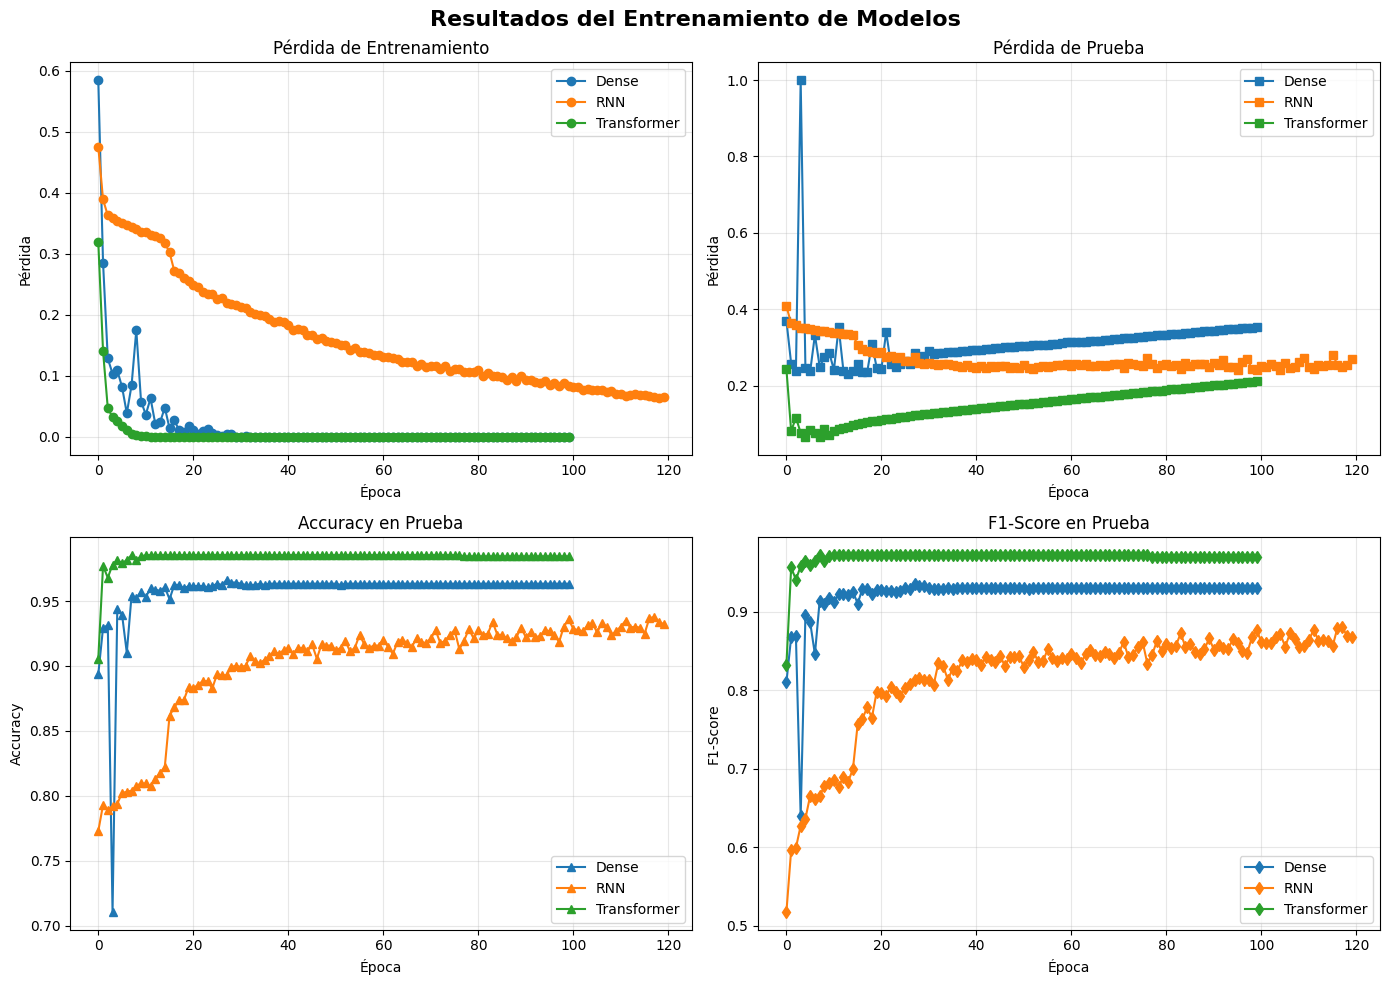

✓ Gráfico de comparación guardado en 'metrics_comparison.png'


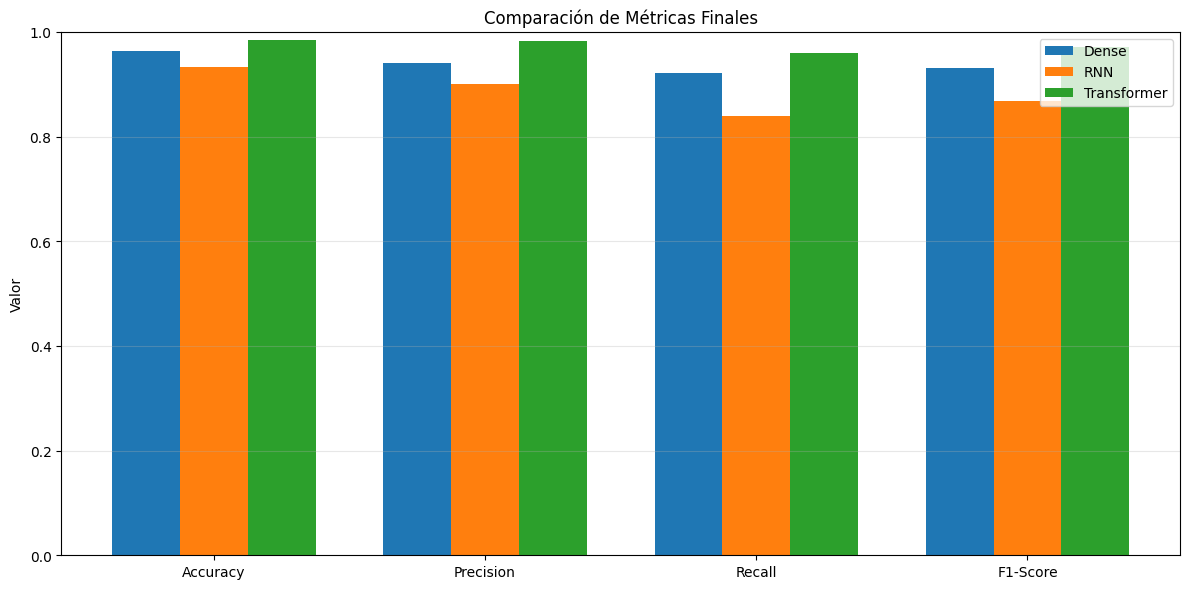

In [59]:
import matplotlib.pyplot as plt

print("\nGenerando gráficos de resultados...\n")

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Resultados del Entrenamiento de Modelos', fontsize=16, fontweight='bold')

# Gráfico 1: Pérdida de entrenamiento
ax = axes[0, 0]
for model_name, results in models_results.items():
    ax.plot(results['history']['train_loss'], label=model_name, marker='o')
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida')
ax.set_title('Pérdida de Entrenamiento')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfico 2: Pérdida de prueba
ax = axes[0, 1]
for model_name, results in models_results.items():
    ax.plot(results['history']['test_loss'], label=model_name, marker='s')
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida')
ax.set_title('Pérdida de Prueba')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfico 3: Accuracy
ax = axes[1, 0]
for model_name, results in models_results.items():
    ax.plot(results['history']['test_accuracy'], label=model_name, marker='^')
ax.set_xlabel('Época')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy en Prueba')
ax.legend()
ax.grid(True, alpha=0.3)

# Gráfico 4: F1-Score
ax = axes[1, 1]
for model_name, results in models_results.items():
    ax.plot(results['history']['test_f1'], label=model_name, marker='d')
ax.set_xlabel('Época')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score en Prueba')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'training_results.png'), dpi=150, bbox_inches='tight')
print("✓ Gráficos guardados en 'training_results.png'")
plt.show()

# Gráfico de comparación de métricas finales
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(models_results.keys())
x = np.arange(len(metrics_names))
width = 0.25

for i, model_name in enumerate(model_names):
    metrics = models_results[model_name]['metrics']
    values = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1']
    ]
    ax.bar(x + i*width, values, width, label=model_name)

ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas Finales')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
print("✓ Gráfico de comparación guardado en 'metrics_comparison.png'")
plt.show()